In [1]:
import pandas as pd
import numpy as np

In [2]:
nav = pd.read_csv("../data/nav_history.csv")

FileNotFoundError: [Errno 2] No such file or directory: '../data/nav_history.csv'

In [3]:
import os
print(os.getcwd())

C:\Users\hp\bluestock_mf_capstone\notebooks


In [4]:
import os
os.listdir()

['.ipynb_checkpoints',
 '01_data_ingestion.ipynb',
 '02_data_cleaning.ipynb',
 '03_eda_analysis.ipynb',
 '04_performance_analytics.ipynb',
 '05_advanced_analytics.ipynb']

In [5]:
import os
print(os.getcwd())

C:\Users\hp\bluestock_mf_capstone\notebooks


In [6]:
os.listdir("../data")

['processed', 'raw']

In [7]:
os.listdir("../data/raw")

['01_fund_master.csv',
 '02_nav_history.csv',
 '03_aum_by_fund_house.csv',
 '04_monthly_sip_inflows.csv',
 '05_category_inflows.csv',
 '06_industry_folio_count.csv',
 '07_scheme_performance.csv',
 '08_investor_transactions.csv',
 '09_portfolio_holdings.csv',
 '10_benchmark_indices.csv',
 'Axis_Bluechip_live_nav.csv',
 'hdfc_top100_nav.csv',
 'HDFC_Top_100_live_nav.csv',
 'ICICI_Bluechip_live_nav.csv',
 'Kotak_Bluechip_live_nav.csv',
 'Nippon_Large_Cap_live_nav.csv',
 'SBI_Bluechip_live_nav.csv']

In [8]:
nav = pd.read_csv("../data/raw/nav_history.csv")

FileNotFoundError: [Errno 2] No such file or directory: '../data/raw/nav_history.csv'

In [9]:
import pandas as pd

nav = pd.read_csv("../data/raw/02_nav_history.csv")

In [10]:
nav.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [11]:
nav.info()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  str    
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 1.1 MB


In [12]:
nav['date'] = pd.to_datetime(nav['date'])

In [13]:
nav = nav.sort_values(
    ['amfi_code', 'date']
)

In [14]:
nav['amfi_code'].nunique()

40

In [15]:
nav['daily_return'] = (
    nav.groupby('amfi_code')['nav']
       .pct_change()
)

In [16]:
nav.head(15)

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210
5755,100016,2022-01-10,510.7136,-0.008639
5756,100016,2022-01-11,513.5542,0.005562
5757,100016,2022-01-12,512.3195,-0.002404
5758,100016,2022-01-13,510.2445,-0.004050
5759,100016,2022-01-14,514.3636,0.008073


In [17]:
nav['daily_return'].isna().sum()

np.int64(40)

In [18]:
nav['daily_return'].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

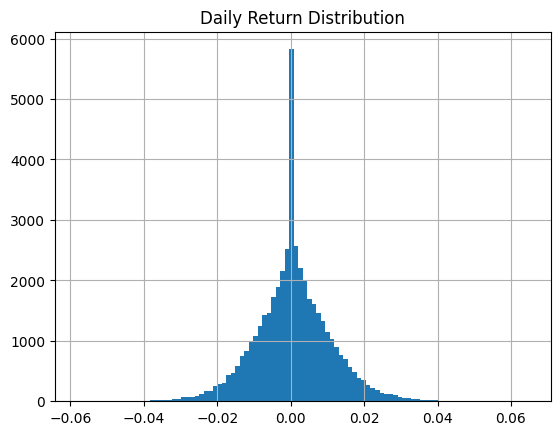

In [19]:
import matplotlib.pyplot as plt

nav['daily_return'].hist(
    bins=100
)

plt.title("Daily Return Distribution")
plt.show()

In [20]:
nav.to_csv(
    "../data/processed/nav_with_returns.csv",
    index=False
)

In [21]:
nav.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


In [22]:
nav['daily_return'].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

In [23]:
nav.groupby('amfi_code').size().describe()

count      40.0
mean     1150.0
std         0.0
min      1150.0
25%      1150.0
50%      1150.0
75%      1150.0
max      1150.0
dtype: float64

In [24]:
nav.groupby('amfi_code').size().head()

amfi_code
100016    1150
100025    1150
100033    1150
101206    1150
101207    1150
dtype: int64

In [25]:
def cagr(start_nav, end_nav, years):
    return ((end_nav / start_nav) ** (1 / years)) - 1

In [26]:
import numpy as np

cagr_results = []

for code, df in nav.groupby('amfi_code'):

    df = df.sort_values('date')

    latest_nav = df.iloc[-1]['nav']

    # 1 Year CAGR
    nav_1y = df.iloc[-252]['nav']
    cagr_1y = cagr(nav_1y, latest_nav, 1)

    # 3 Year CAGR
    nav_3y = df.iloc[-756]['nav']
    cagr_3y = cagr(nav_3y, latest_nav, 3)

    # 5 Year CAGR
    cagr_5y = np.nan

    cagr_results.append([
        code,
        cagr_1y,
        cagr_3y,
        cagr_5y
    ])

In [27]:
cagr_df = pd.DataFrame(
    cagr_results,
    columns=[
        'amfi_code',
        'cagr_1y',
        'cagr_3y',
        'cagr_5y'
    ]
)

In [28]:
cagr_df.head()

,amfi_code,cagr_1y,cagr_3y,cagr_5y
0,100016,-0.033055,-0.000316,NaN
1,100025,0.025018,0.046143,NaN
2,100033,0.477346,0.336292,NaN
3,101206,0.450939,0.325286,NaN
4,101207,-0.242421,-0.026965,NaN


In [29]:
cagr_df.sort_values(
    'cagr_3y',
    ascending=False
).head(10)

,amfi_code,cagr_1y,cagr_3y,cagr_5y
16,119094,0.309182,0.360660,NaN
2,100033,0.477346,0.336292,NaN
3,101206,0.450939,0.325286,NaN
34,148567,0.145807,0.312786,NaN
25,120505,0.303534,0.302065,NaN
24,120504,0.115007,0.283698,NaN
21,119598,0.845322,0.278144,NaN
19,119551,0.488839,0.277274,NaN
8,102887,0.127279,0.256630,NaN
30,120843,0.284811,0.256619,NaN


In [30]:
cagr_df.to_csv(
    "../data/processed/cagr_table.csv",
    index=False
)

In [31]:
cagr_df.sort_values(
    'cagr_3y',
    ascending=False
).head()

,amfi_code,cagr_1y,cagr_3y,cagr_5y
16,119094,0.309182,0.360660,NaN
2,100033,0.477346,0.336292,NaN
3,101206,0.450939,0.325286,NaN
34,148567,0.145807,0.312786,NaN
25,120505,0.303534,0.302065,NaN


In [32]:
RF = 0.065

In [33]:
import numpy as np

sharpe_results = []

for code, df in nav.groupby('amfi_code'):

    r = df['daily_return'].dropna()

    excess_return = r - (RF / 252)

    sharpe = (
        excess_return.mean()
        /
        r.std()
    ) * np.sqrt(252)

    sharpe_results.append([
        code,
        sharpe
    ])

In [34]:
sharpe_df = pd.DataFrame(
    sharpe_results,
    columns=[
        'amfi_code',
        'sharpe_ratio'
    ]
)

In [35]:
sharpe_df = sharpe_df.sort_values(
    'sharpe_ratio',
    ascending=False
)

In [36]:
sharpe_df.head(10)

,amfi_code,sharpe_ratio
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101
38,149323,1.132122
2,100033,1.093699
9,118632,1.081659
3,101206,1.027213
24,120504,1.026524


In [37]:
sharpe_df.to_csv(
    "../data/processed/sharpe_ratio.csv",
    index=False
)

In [38]:
sharpe_df.head()

,amfi_code,sharpe_ratio
34,148567,1.448291
30,120843,1.306744
36,148569,1.234930
19,119551,1.208267
25,120505,1.180101


In [39]:
sortino_results = []

for code, df in nav.groupby('amfi_code'):

    r = df['daily_return'].dropna()

    downside = r[r < 0]

    downside_std = downside.std()

    sortino = (
        (r.mean() - RF/252)
        /
        downside_std
    ) * np.sqrt(252)

    sortino_results.append([
        code,
        sortino
    ])

In [40]:
sortino_df = pd.DataFrame(
    sortino_results,
    columns=[
        'amfi_code',
        'sortino_ratio'
    ]
)

In [41]:
sortino_df = sortino_df.sort_values(
    'sortino_ratio',
    ascending=False
)

In [42]:
sortino_df.head()

,amfi_code,sortino_ratio
34,148567,2.385644
30,120843,2.364320
36,148569,2.146914
19,119551,2.140267
25,120505,2.029353


In [43]:
sortino_df.to_csv(
    "../data/processed/sortino_ratio.csv",
    index=False
)

In [44]:
sortino_df.head()

,amfi_code,sortino_ratio
34,148567,2.385644
30,120843,2.364320
36,148569,2.146914
19,119551,2.140267
25,120505,2.029353


In [45]:
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

In [46]:
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [47]:
benchmark.columns.tolist()

['date', 'index_name', 'close_value']

In [48]:
benchmark['index_name'].unique()

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str

In [49]:
benchmark['date'] = pd.to_datetime(
    benchmark['date']
)

In [50]:
nifty100 = benchmark[
    benchmark['index_name'] == 'NIFTY100'
].copy()

In [51]:
nifty100 = nifty100.sort_values('date')

nifty100['benchmark_return'] = (
    nifty100['close_value']
    .pct_change()
)

In [52]:
nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [53]:
fund_returns = nav[
    ['amfi_code','date','daily_return']
]

In [54]:
merged = pd.merge(
    fund_returns,
    nifty100[['date','benchmark_return']],
    on='date',
    how='inner'
)

In [55]:
merged.head()

,amfi_code,date,daily_return,benchmark_return
0,100016,2022-01-03,NaN,NaN
1,100016,2022-01-04,-0.010306,-0.013540
2,100016,2022-01-05,0.012865,0.004003
3,100016,2022-01-06,-0.011377,-0.002935
4,100016,2022-01-07,-0.001210,0.006150


In [56]:
from scipy.stats import linregress

ModuleNotFoundError: No module named 'scipy'

In [57]:
import sys
print(sys.executable)

C:\Users\hp\AppData\Local\Python\pythoncore-3.14-64\python.exe


In [58]:
%pip install scipy

  Using cached scipy-1.17.1-cp314-cp314-win_amd64.whl.metadata (60 kB)
Using cached scipy-1.17.1-cp314-cp314-win_amd64.whl (37.3 MB)
Note: you may need to restart the kernel to use updated packages.


In [59]:
import scipy
print(scipy.__version__)

1.17.1


In [60]:
from scipy.stats import linregress

In [61]:
alpha_beta_results = []

In [62]:
for code, df in merged.groupby('amfi_code'):

    df = df.dropna()

    slope, intercept, r_value, p_value, std_err = linregress(
        df['benchmark_return'],
        df['daily_return']
    )

    beta = slope
    alpha = intercept * 252

    alpha_beta_results.append([
        code,
        alpha,
        beta,
        r_value**2
    ])

In [63]:
alpha_beta_df = pd.DataFrame(
    alpha_beta_results,
    columns=[
        'amfi_code',
        'alpha',
        'beta',
        'r_squared'
    ]
)

In [64]:
alpha_beta_df.sort_values(
    'alpha',
    ascending=False
).head()

,amfi_code,alpha,beta,r_squared
21,119598,0.303370,-0.023196,1.414258e-04
39,149324,0.300579,0.011455,3.532991e-05
25,120505,0.292636,0.000549,1.345534e-07
36,148569,0.282704,0.018134,1.748889e-04
30,120843,0.273305,-0.022830,3.430543e-04


In [65]:
alpha_beta_df.to_csv(
    "../outputs/alpha_beta.csv",
    index=False
)

OSError: Cannot save file into a non-existent directory: '..\outputs'

In [66]:
import os

os.makedirs("../outputs", exist_ok=True)

In [67]:
alpha_beta_df.to_csv(
    "../outputs/alpha_beta.csv",
    index=False
)

In [68]:
alpha_beta_df.sort_values(
    'alpha',
    ascending=False
).head()

,amfi_code,alpha,beta,r_squared
21,119598,0.303370,-0.023196,1.414258e-04
39,149324,0.300579,0.011455,3.532991e-05
25,120505,0.292636,0.000549,1.345534e-07
36,148569,0.282704,0.018134,1.748889e-04
30,120843,0.273305,-0.022830,3.430543e-04


In [69]:
benchmark['index_name'].unique()

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str

In [70]:
nifty100 = benchmark[
    benchmark['index_name'] == 'NIFTY100'
].copy()

print(nifty100.shape)
print(nifty100['date'].min(), nifty100['date'].max())

(1150, 3)
2022-01-03 00:00:00 2026-05-29 00:00:00


In [71]:
print(nav['date'].min(), nav['date'].max())

2022-01-03 00:00:00 2026-05-29 00:00:00


In [72]:
print(merged.shape)

(46000, 4)


In [73]:
merged[['date','daily_return','benchmark_return']].head(20)

,date,daily_return,benchmark_return
0,2022-01-03,NaN,NaN
1,2022-01-04,-0.010306,-0.013540
2,2022-01-05,0.012865,0.004003
3,2022-01-06,-0.011377,-0.002935
4,2022-01-07,-0.001210,0.006150
5,2022-01-10,-0.008639,-0.008351
6,2022-01-11,0.005562,0.004942
7,2022-01-12,-0.002404,0.009128
8,2022-01-13,-0.004050,0.003746
9,2022-01-14,0.008073,-0.014098


In [74]:
nifty100.head(10)

,date,index_name,close_value
1150,2022-01-03,NIFTY100,17778.24
1151,2022-01-04,NIFTY100,17537.52
1152,2022-01-05,NIFTY100,17607.73
1153,2022-01-06,NIFTY100,17556.05
1154,2022-01-07,NIFTY100,17664.02
1155,2022-01-10,NIFTY100,17516.51
1156,2022-01-11,NIFTY100,17603.08
1157,2022-01-12,NIFTY100,17763.76
1158,2022-01-13,NIFTY100,17830.30
1159,2022-01-14,NIFTY100,17578.93


In [75]:
benchmark['date'] = pd.to_datetime(benchmark['date'])

nifty100 = benchmark[
    benchmark['index_name'] == 'NIFTY100'
].copy()

nifty100 = nifty100.sort_values('date')

In [76]:
nifty100['benchmark_return'] = (
    nifty100['close_value'].pct_change()
)

In [77]:
nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [78]:
nifty100['benchmark_return'].describe()

count    1149.000000
mean        0.000122
std         0.008119
min        -0.026873
25%        -0.005385
50%        -0.000112
75%         0.005456
max         0.026795
Name: benchmark_return, dtype: float64

In [79]:
merged = pd.merge(
    nav[['amfi_code','date','daily_return']],
    nifty100[['date','benchmark_return']],
    on='date',
    how='inner'
)

In [80]:
from scipy.stats import linregress

sample = merged[
    merged['amfi_code'] == 120505
].dropna()

result = linregress(
    sample['benchmark_return'],
    sample['daily_return']
)

print("Beta =", result.slope)
print("Alpha =", result.intercept * 252)
print("R² =", result.rvalue**2)

Beta = 0.000549004250631712
Alpha = 0.2926358334175106
R² = 1.3455341675668847e-07


In [81]:
nav.groupby('amfi_code')['nav'].agg(['min','max']).head(10)

,min,max
amfi_code,,
100016,411.1759,669.7236
100025,26.1366,32.6726
100033,93.5553,367.6979
101206,297.0795,808.0982
101207,36.9015,80.3517
101208,310.6977,410.1021
102885,83.5999,187.9295
102886,114.1285,169.8164
102887,149.9155,419.3008


In [82]:
nav.pivot_table(
    index='date',
    columns='amfi_code',
    values='nav'
).corr().iloc[:5,:5]

amfi_code,100016,100025,100033,101206,101207
amfi_code,,,,,
100016,1.000000,0.585294,0.653467,0.566001,0.635922
100025,0.585294,1.000000,0.912157,0.913252,0.574509
100033,0.653467,0.912157,1.000000,0.952862,0.594425
101206,0.566001,0.913252,0.952862,1.000000,0.435032
101207,0.635922,0.574509,0.594425,0.435032,1.000000


In [83]:
sample[['daily_return','benchmark_return']].corr()

,daily_return,benchmark_return
daily_return,1.000000,0.000367
benchmark_return,0.000367,1.000000


In [84]:
sample['benchmark_return'].describe()

count    1149.000000
mean        0.000122
std         0.008119
min        -0.026873
25%        -0.005385
50%        -0.000112
75%         0.005456
max         0.026795
Name: benchmark_return, dtype: float64

In [85]:
sample['daily_return'].describe()

count    1149.000000
mean        0.001161
std         0.012152
min        -0.038418
25%        -0.007237
50%         0.000955
75%         0.009359
max         0.040812
Name: daily_return, dtype: float64

In [86]:
alpha_beta_df.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

In [87]:
def max_drawdown_info(df):
    nav_series = df['nav']

    running_max = nav_series.cummax()
    drawdown = nav_series / running_max - 1

    mdd = drawdown.min()

    end_idx = drawdown.idxmin()
    start_idx = nav_series[:end_idx+1].idxmax()

    return mdd, start_idx, end_idx

In [88]:
drawdown_results = []

for code, df in nav.groupby('amfi_code'):
    df = df.sort_values('date').reset_index(drop=True)

    mdd, start_idx, end_idx = max_drawdown_info(df)

    drawdown_results.append([
        code,
        mdd,
        df.loc[start_idx, 'date'],
        df.loc[end_idx, 'date']
    ])

drawdown_df = pd.DataFrame(
    drawdown_results,
    columns=[
        'amfi_code',
        'max_drawdown',
        'peak_date',
        'trough_date'
    ]
)

In [89]:
drawdown_df.sort_values('max_drawdown').head()

,amfi_code,max_drawdown,peak_date,trough_date
22,119599,-0.525742,2023-01-17,2025-10-28
17,119095,-0.516778,2025-05-22,2026-05-11
4,101207,-0.354469,2024-11-21,2026-05-11
39,149324,-0.311719,2024-05-03,2025-01-03
21,119598,-0.287060,2024-08-28,2025-05-14


In [90]:
drawdown_df.to_csv(
    "../data/processed/max_drawdown.csv",
    index=False
)

In [91]:
scorecard = (
    cagr_df
    .merge(sharpe_df, on='amfi_code')
    .merge(sortino_df, on='amfi_code')
    .merge(alpha_beta_df, on='amfi_code')
    .merge(drawdown_df[['amfi_code','max_drawdown']], on='amfi_code')
)

In [92]:
scorecard.head()

,amfi_code,cagr_1y,cagr_3y,cagr_5y,sharpe_ratio,sortino_ratio,alpha,beta,r_squared,max_drawdown
0,100016,-0.033055,-0.000316,NaN,-0.201517,-0.351047,0.037476,-0.058268,0.002665,-0.247344
1,100025,0.025018,0.046143,NaN,-0.567095,-0.941821,0.042818,0.001158,0.000015,-0.043083
2,100033,0.477346,0.336292,NaN,1.093699,1.829134,0.271954,0.005104,0.000012,-0.162172
3,101206,0.450939,0.325286,NaN,1.027213,1.799563,0.213998,0.021086,0.000348,-0.112916
4,101207,-0.242421,-0.026965,NaN,0.162661,0.276644,0.108971,-0.065289,0.001064,-0.354469


In [93]:
scorecard['cagr_rank'] = (
    scorecard['cagr_3y']
    .rank(ascending=False)
)

In [94]:
scorecard['sharpe_rank'] = (
    scorecard['sharpe_ratio']
    .rank(ascending=False)
)

In [95]:
scorecard['alpha_rank'] = (
    scorecard['alpha']
    .rank(ascending=False)
)

In [96]:
scorecard['dd_rank'] = (
    scorecard['max_drawdown']
    .rank(ascending=False)
)

In [97]:
scorecard['fund_score'] = (
      0.40 * scorecard['cagr_rank']
    + 0.30 * scorecard['sharpe_rank']
    + 0.20 * scorecard['alpha_rank']
    + 0.10 * scorecard['dd_rank']
)

In [98]:
scorecard['fund_score'] = (
    scorecard['fund_score'].max()
    - scorecard['fund_score']
)

In [99]:
scorecard['fund_score'] = (
    scorecard['fund_score']
    / scorecard['fund_score'].max()
) * 100

In [100]:
scorecard.sort_values(
    'fund_score',
    ascending=False
).head(10)

,amfi_code,cagr_1y,cagr_3y,cagr_5y,sharpe_ratio,sortino_ratio,alpha,beta,r_squared,max_drawdown,cagr_rank,sharpe_rank,alpha_rank,dd_rank,fund_score
34,148567,0.145807,0.312786,NaN,1.448291,2.385644,0.269838,0.023684,4.625437e-04,-0.112657,4.0,1.0,7.0,8.0,100.000000
2,100033,0.477346,0.336292,NaN,1.093699,1.829134,0.271954,0.005104,1.206652e-05,-0.162172,2.0,7.0,6.0,20.0,94.011976
25,120505,0.303534,0.302065,NaN,1.180101,2.029353,0.292636,0.000549,1.345534e-07,-0.181885,5.0,5.0,3.0,25.0,92.514970
30,120843,0.284811,0.256619,NaN,1.306744,2.364320,0.273305,-0.022830,3.430543e-04,-0.129740,10.0,2.0,5.0,13.0,91.616766
3,101206,0.450939,0.325286,NaN,1.027213,1.799563,0.213998,0.021086,3.480482e-04,-0.112916,3.0,9.0,12.0,9.0,90.718563
19,119551,0.488839,0.277274,NaN,1.208267,2.140267,0.232010,-0.031751,8.869789e-04,-0.150124,8.0,4.0,10.0,17.0,88.023952
16,119094,0.309182,0.360660,NaN,0.998231,1.703797,0.260767,-0.066265,1.936879e-03,-0.209609,1.0,11.0,9.0,28.0,87.425150
36,148569,0.444657,0.233171,NaN,1.234930,2.146914,0.282704,0.018134,1.748889e-04,-0.163967,13.0,3.0,4.0,21.0,85.329341
24,120504,0.115007,0.283698,NaN,1.026524,1.805294,0.211948,0.016232,2.121613e-04,-0.125883,6.0,10.0,13.0,12.0,84.730539
38,149323,0.223056,0.242425,NaN,1.132122,1.875101,0.265986,-0.002523,3.357978e-06,-0.172481,12.0,6.0,8.0,22.0,81.137725


In [101]:
scorecard.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

In [102]:
scorecard.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

In [103]:
top5_codes = top5['amfi_code'].tolist()
print(top5_codes)

NameError: name 'top5' is not defined

In [104]:
top5 = scorecard.sort_values(
    'fund_score',
    ascending=False
).head(5)

top5

,amfi_code,cagr_1y,cagr_3y,cagr_5y,sharpe_ratio,sortino_ratio,alpha,beta,r_squared,max_drawdown,cagr_rank,sharpe_rank,alpha_rank,dd_rank,fund_score
34,148567,0.145807,0.312786,NaN,1.448291,2.385644,0.269838,0.023684,4.625437e-04,-0.112657,4.0,1.0,7.0,8.0,100.000000
2,100033,0.477346,0.336292,NaN,1.093699,1.829134,0.271954,0.005104,1.206652e-05,-0.162172,2.0,7.0,6.0,20.0,94.011976
25,120505,0.303534,0.302065,NaN,1.180101,2.029353,0.292636,0.000549,1.345534e-07,-0.181885,5.0,5.0,3.0,25.0,92.514970
30,120843,0.284811,0.256619,NaN,1.306744,2.364320,0.273305,-0.022830,3.430543e-04,-0.129740,10.0,2.0,5.0,13.0,91.616766
3,101206,0.450939,0.325286,NaN,1.027213,1.799563,0.213998,0.021086,3.480482e-04,-0.112916,3.0,9.0,12.0,9.0,90.718563


In [105]:
top5_codes = top5['amfi_code'].tolist()
print(top5_codes)

[148567, 100033, 120505, 120843, 101206]


In [106]:
nifty50 = benchmark[
    benchmark['index_name'] == 'NIFTY50'
].copy()

nifty50 = nifty50.sort_values('date')

nifty50['return'] = (
    nifty50['close_value']
    .pct_change()
)

In [107]:
nifty100 = benchmark[
    benchmark['index_name'] == 'NIFTY100'
].copy()

nifty100 = nifty100.sort_values('date')

nifty100['return'] = (
    nifty100['close_value']
    .pct_change()
)

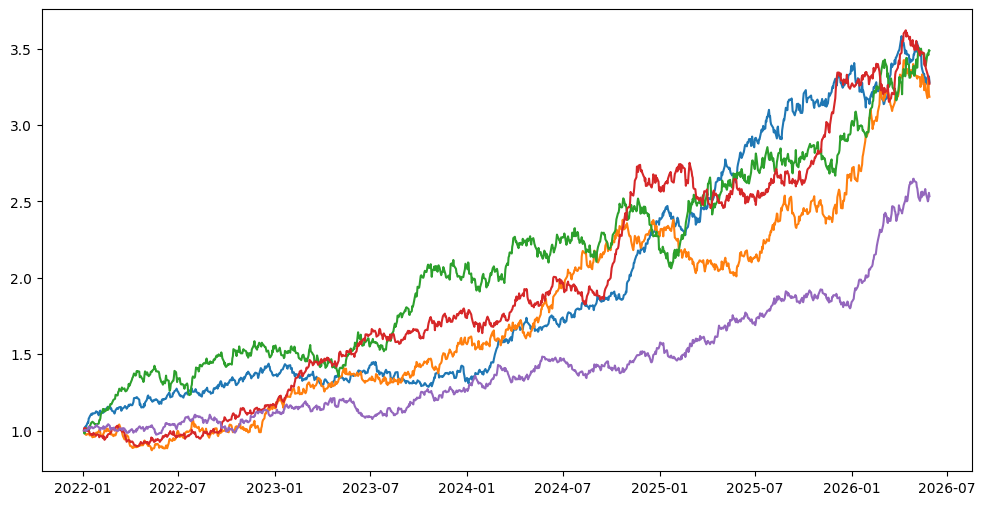

In [108]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for code in top5_codes:

    df = nav[
        nav['amfi_code'] == code
    ].copy()

    df = df.sort_values('date')

    cumulative = (
        1 + df['daily_return'].fillna(0)
    ).cumprod()

    plt.plot(
        df['date'],
        cumulative,
        label=f'Fund {code}'
    )

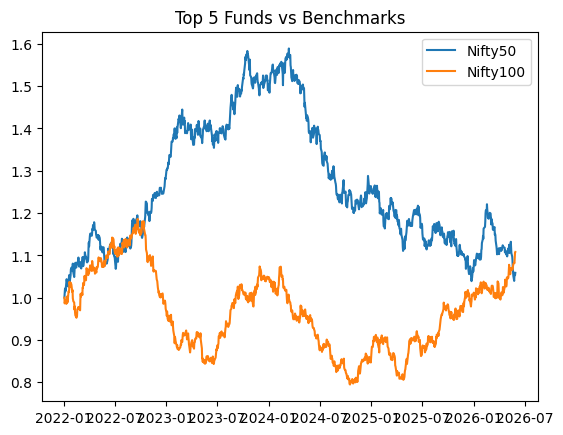

In [109]:
n50 = (
    1 + nifty50['return'].fillna(0)
).cumprod()

plt.plot(
    nifty50['date'],
    n50,
    label='Nifty50'
)

n100 = (
    1 + nifty100['return'].fillna(0)
).cumprod()

plt.plot(
    nifty100['date'],
    n100,
    label='Nifty100'
)

plt.legend()
plt.title('Top 5 Funds vs Benchmarks')
plt.show()

In [110]:
plt.savefig(
    "../data/processed/benchmark_chart.png",
    bbox_inches='tight'
)

<Figure size 640x480 with 0 Axes>

In [111]:
tracking_error = []

In [112]:
for code in top5_codes:

    fund = nav[
        nav['amfi_code'] == code
    ][['date','daily_return']]

    temp = fund.merge(
        nifty100[['date','return']],
        on='date'
    )

    te = (
        (temp['daily_return'] - temp['return'])
        .std()
        * np.sqrt(252)
    )

    tracking_error.append(
        [code, te]
    )

In [113]:
tracking_df = pd.DataFrame(
    tracking_error,
    columns=[
        'amfi_code',
        'tracking_error'
    ]
)

tracking_df

,amfi_code,tracking_error
0,148567,0.189664
1,100033,0.228699
2,120505,0.231968
3,120843,0.206425
4,101206,0.192706
